DATOS CARGADOS
Shape T1: (160, 192, 64)
Shape T2: (160, 192, 64)
T1 min/max: 0.0 2500.0
T2 min/max: 0.0 450.0


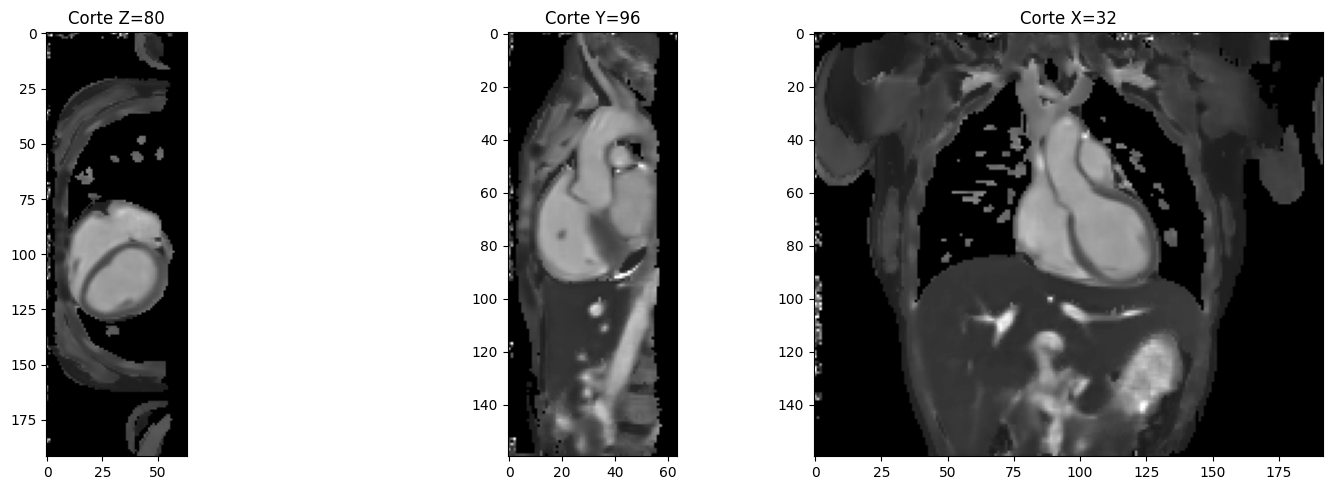

Suavizado gaussiano aplicado.


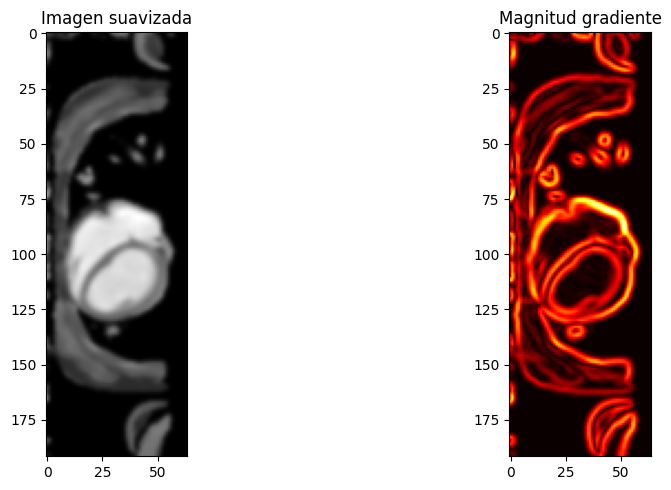

LANDMARKS
Apex: [10. 96. 80.]
Base: [55. 96. 80.]
Lateral: [ 30. 120.  80.]
EJE LARGO
Vector eje: [1. 0. 0.]
VERIFICACIÓN ORTOGONALIDAD
dot(eje,u): 0.0
dot(eje,v): 0.0
dot(u,v): 0.0
norm eje: 1.0
norm u: 1.0
norm v: 1.0
GENERANDO SAX...
SAX generado.
VALIDACIÓN
T1 SAX min/max: 0.0 1852.2090215127926
T2 SAX min/max: 0.0 425.356837881109


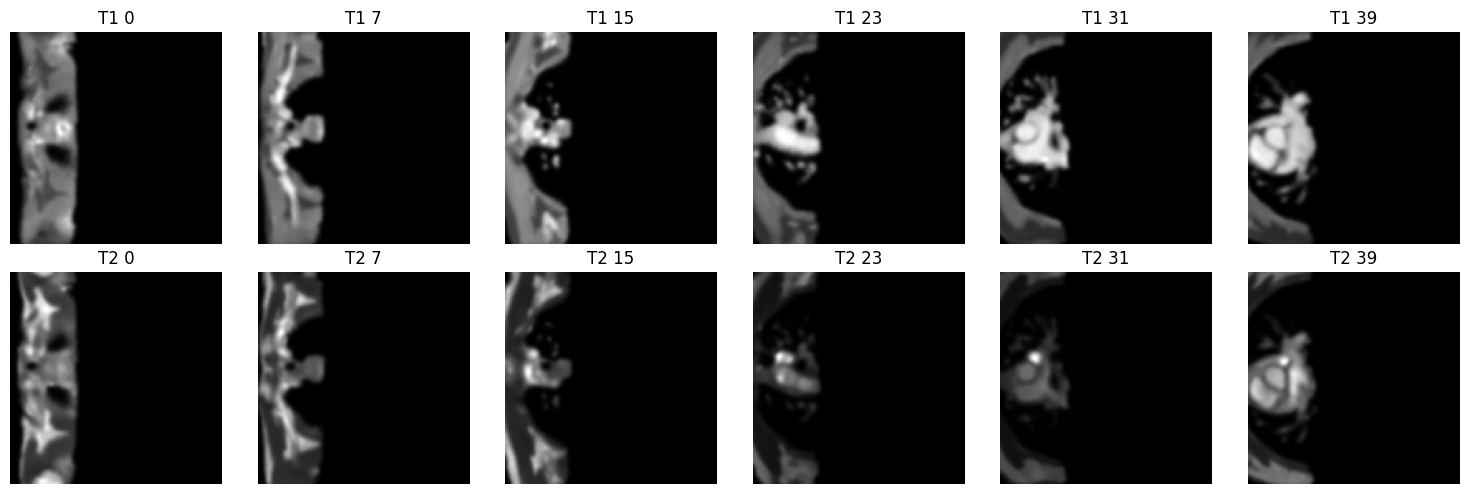

PIPELINE FINALIZADO
Archivos exportados:
- mapa_T1_SAX.npy
- mapa_T2_SAX.npy
- resultado_SAX.png
Metadata:
{'p_apex': [10.0, 96.0, 80.0], 'p_base': [55.0, 96.0, 80.0], 'p_lateral': [30.0, 120.0, 80.0], 'eje_largo': [1.0, 0.0, 0.0], 'u': [0.0, 0.0, 1.0], 'v': [0.0, -1.0, 0.0], 'sigma_gaussiano': 1.0, 'nslices': 40}


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import (
    gaussian_filter,
    sobel,
    map_coordinates
)

# =========================================================
# 1. CARGA DE DATOS
# =========================================================

t1 = np.load("mapa_T1.npy")
t2 = np.load("mapa_T2.npy")

# Limpieza básica de NaN
t1 = np.nan_to_num(t1, nan=0.0)
t2 = np.nan_to_num(t2, nan=0.0)

print("===================================")
print("DATOS CARGADOS")
print("===================================")

print("Shape T1:", t1.shape)
print("Shape T2:", t2.shape)

print("T1 min/max:", np.min(t1), np.max(t1))
print("T2 min/max:", np.min(t2), np.max(t2))

# =========================================================
# 2. VISUALIZACIÓN INICIAL
# Verificar orientación del volumen
# =========================================================

mid_z = t1.shape[0] // 2
mid_y = t1.shape[1] // 2
mid_x = t1.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(t1[mid_z, :, :], cmap='gray')
axes[0].set_title(f'Corte Z={mid_z}')

axes[1].imshow(t1[:, mid_y, :], cmap='gray')
axes[1].set_title(f'Corte Y={mid_y}')

axes[2].imshow(t1[:, :, mid_x], cmap='gray')
axes[2].set_title(f'Corte X={mid_x}')

plt.tight_layout()
plt.show()

# =========================================================
# 3. SUAVIZADO GAUSSIANO
# Reduce ruido antes de detección de bordes
# =========================================================

sigma = 1.0

t1_smooth = gaussian_filter(t1, sigma=sigma)
t2_smooth = gaussian_filter(t2, sigma=sigma)

print("Suavizado gaussiano aplicado.")

# =========================================================
# 4. VISUALIZACIÓN DE BORDES
# Basado en gradientes tipo Sobel
# =========================================================

slice_mid = t1.shape[0] // 2

gx = sobel(t1_smooth[slice_mid], axis=0)
gy = sobel(t1_smooth[slice_mid], axis=1)

gradiente = np.sqrt(gx**2 + gy**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(t1_smooth[slice_mid], cmap='gray')
axes[0].set_title("Imagen suavizada")

axes[1].imshow(gradiente, cmap='hot')
axes[1].set_title("Magnitud gradiente")

plt.tight_layout()
plt.show()

# =========================================================
# 5. LANDMARKS MANUALES
# Coordenadas [Z, Y, X]
# =========================================================
#
# IMPORTANTE:
# Debes cambiar estos valores manualmente
# luego de inspeccionar las imágenes.
#
# p_apex  -> punta inferior del VI
# p_base  -> centro aproximado de la válvula mitral
# p_lateral -> punto lateral para fijar orientación
#
# =========================================================

p_apex = np.array([10, 96, 80], dtype=float)

p_base = np.array([55, 96, 80], dtype=float)

p_lateral = np.array([30, 120, 80], dtype=float)

print("===================================")
print("LANDMARKS")
print("===================================")

print("Apex:", p_apex)
print("Base:", p_base)
print("Lateral:", p_lateral)

# =========================================================
# 6. EJE LARGO
# =========================================================

eje = p_base - p_apex
eje = eje / np.linalg.norm(eje)

print("===================================")
print("EJE LARGO")
print("===================================")

print("Vector eje:", eje)

# =========================================================
# 7. BASE ORTONORMAL
# SIN GRAM-SCHMIDT
# =========================================================

aux = p_lateral - p_apex
aux = aux / np.linalg.norm(aux)

u = np.cross(eje, aux)
u = u / np.linalg.norm(u)

v = np.cross(eje, u)
v = v / np.linalg.norm(v)

print("===================================")
print("VERIFICACIÓN ORTOGONALIDAD")
print("===================================")

print("dot(eje,u):", np.dot(eje, u))
print("dot(eje,v):", np.dot(eje, v))
print("dot(u,v):", np.dot(u, v))

print("norm eje:", np.linalg.norm(eje))
print("norm u:", np.linalg.norm(u))
print("norm v:", np.linalg.norm(v))

# =========================================================
# 8. REFORMATEO SAX
# =========================================================

def reformatear_sax(
    volumen,
    apex,
    base,
    eje,
    u,
    v,
    tamaño=128,
    nslices=40
):

    sax = np.zeros((nslices, tamaño, tamaño))

    # Rango del plano en VOXELES
    half_size = tamaño // 2

    rango = np.linspace(
        -half_size,
        half_size,
        tamaño
    )

    UU, VV = np.meshgrid(rango, rango)

    # Longitud del eje largo
    longitud = np.linalg.norm(base - apex)

    offsets = np.linspace(
        0,
        longitud,
        nslices
    )

    for i, d in enumerate(offsets):

        # Centro del slice actual
        centro = apex + d * eje

        # Construcción de puntos del plano SAX
        puntos = (
            centro[None, None, :]
            + UU[:, :, None] * u[None, None, :]
            + VV[:, :, None] * v[None, None, :]
        )

        # Coordenadas para interpolación
        coords = [
            puntos[:, :, 0].ravel(),
            puntos[:, :, 1].ravel(),
            puntos[:, :, 2].ravel()
        ]

        # Interpolación lineal
        valores = map_coordinates(
            volumen,
            coords,
            order=1,
            mode='constant',
            cval=0.0
        )

        sax[i] = valores.reshape(
            tamaño,
            tamaño
        )

    return sax

# =========================================================
# 9. GENERACIÓN SAX
# =========================================================

print("===================================")
print("GENERANDO SAX...")
print("===================================")

t1_sax = reformatear_sax(
    volumen=t1_smooth,
    apex=p_apex,
    base=p_base,
    eje=eje,
    u=u,
    v=v,
    tamaño=128,
    nslices=40
)

t2_sax = reformatear_sax(
    volumen=t2_smooth,
    apex=p_apex,
    base=p_base,
    eje=eje,
    u=u,
    v=v,
    tamaño=128,
    nslices=40
)

print("SAX generado.")

# =========================================================
# 10. VALIDACIÓN NUMÉRICA
# =========================================================

print("===================================")
print("VALIDACIÓN")
print("===================================")

print("T1 SAX min/max:",
      np.min(t1_sax),
      np.max(t1_sax))

print("T2 SAX min/max:",
      np.min(t2_sax),
      np.max(t2_sax))

# =========================================================
# 11. VISUALIZACIÓN SAX
# =========================================================

nslices = t1_sax.shape[0]

indices = np.linspace(
    0,
    nslices - 1,
    6,
    dtype=int
)

fig, axes = plt.subplots(
    2,
    6,
    figsize=(15, 5)
)

for j, idx in enumerate(indices):

    # T1
    axes[0, j].imshow(
        t1_sax[idx],
        cmap='gray',
        origin='lower'
    )

    axes[0, j].axis('off')

    axes[0, j].set_title(
        f"T1 {idx}"
    )

    # T2
    axes[1, j].imshow(
        t2_sax[idx],
        cmap='gray',
        origin='lower'
    )

    axes[1, j].axis('off')

    axes[1, j].set_title(
        f"T2 {idx}"
    )

plt.tight_layout()

plt.savefig(
    "resultado_SAX.png",
    dpi=300
)

plt.show()

# =========================================================
# 12. EXPORTACIÓN
# =========================================================

np.save(
    "mapa_T1_SAX.npy",
    t1_sax
)

np.save(
    "mapa_T2_SAX.npy",
    t2_sax
)

# =========================================================
# 13. GUARDAR METADATA
# =========================================================

metadata = {
    "p_apex": p_apex.tolist(),
    "p_base": p_base.tolist(),
    "p_lateral": p_lateral.tolist(),
    "eje_largo": eje.tolist(),
    "u": u.tolist(),
    "v": v.tolist(),
    "sigma_gaussiano": sigma,
    "nslices": int(nslices)
}

print("===================================")
print("PIPELINE FINALIZADO")
print("===================================")

print("Archivos exportados:")
print("- mapa_T1_SAX.npy")
print("- mapa_T2_SAX.npy")
print("- resultado_SAX.png")

print("Metadata:")
print(metadata)


DATOS
Shape: (160, 192, 64)


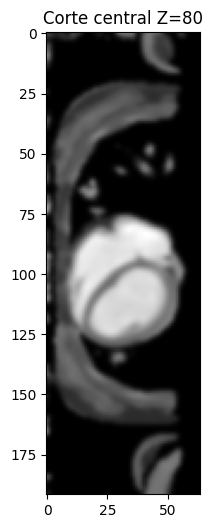

Threshold: 558.7628867224986
Número componentes: 228
Componente seleccionada: 12


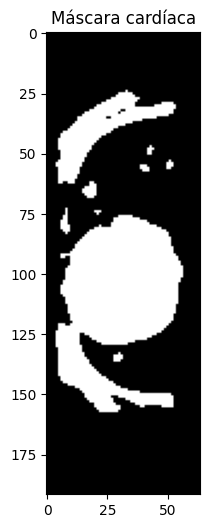

BOUNDING BOX
z: 0 159
y: 19 191
x: 0 63
LANDMARKS
Apex: [ 0.         95.84373825 33.09680473]
Base: [159.          95.84373825  33.09680473]
Lateral: [ 78.79157443 191.          33.09680473]


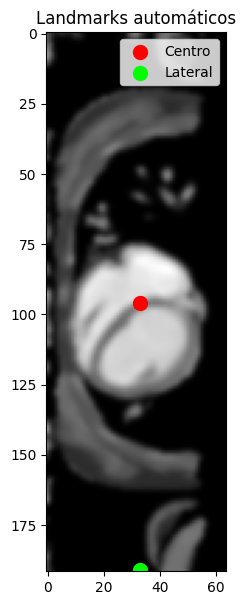

EJE
[1. 0. 0.]
ORTOGONALIDAD
0.0
0.0
0.0
VALIDACIÓN SAX
T1 min/max: 0.0 2474.610538955669
T2 min/max: 0.0 436.03694862281696


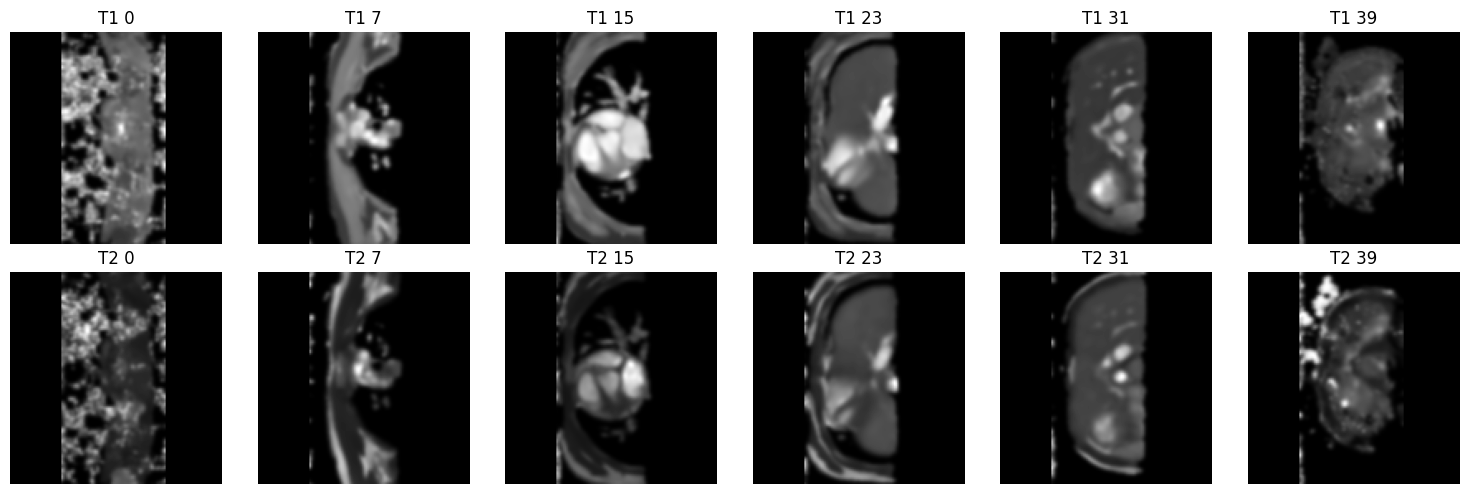

PIPELINE SEMI-AUTOMÁTICO FINALIZADO


In [11]:

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import (
    gaussian_filter,
    label,
    sobel,
    map_coordinates
)

# =========================================================
# 1. CARGA
# =========================================================

t1 = np.load("mapa_T1.npy")
t2 = np.load("mapa_T2.npy")

t1 = np.nan_to_num(t1, nan=0.0)
t2 = np.nan_to_num(t2, nan=0.0)

print("===================================")
print("DATOS")
print("===================================")

print("Shape:", t1.shape)

# =========================================================
# 2. SUAVIZADO
# =========================================================

sigma = 1.0

t1_smooth = gaussian_filter(t1, sigma=sigma)
t2_smooth = gaussian_filter(t2, sigma=sigma)

# =========================================================
# 3. VISUALIZACIÓN BÁSICA
# =========================================================

mid_z = t1.shape[0] // 2

plt.figure(figsize=(6,6))

plt.imshow(
    t1_smooth[mid_z],
    cmap='gray'
)

plt.title(f"Corte central Z={mid_z}")

plt.show()

# =========================================================
# 4. SEGMENTACIÓN SEMI-AUTOMÁTICA
# =========================================================

# Usar solo voxeles válidos
voxels_validos = t1_smooth[t1_smooth > 0]

threshold = np.percentile(
    voxels_validos,
    70
)

print("Threshold:", threshold)

mask = t1_smooth > threshold

# =========================================================
# 5. COMPONENTES CONECTADAS
# =========================================================

labels, nlabels = label(mask)

print("Número componentes:", nlabels)

# =========================================================
# 6. BUSCAR COMPONENTE CENTRAL MÁS GRANDE
# =========================================================

center = np.array(t1.shape) // 2

best_label = None
best_score = -np.inf

for i in range(1, nlabels + 1):

    coords = np.argwhere(labels == i)

    if len(coords) < 1000:
        continue

    centroid = coords.mean(axis=0)

    distance = np.linalg.norm(
        centroid - center
    )

    size = len(coords)

    # favorecer regiones grandes y centrales
    score = size - 20 * distance

    if score > best_score:
        best_score = score
        best_label = i

mask_heart = labels == best_label

print("Componente seleccionada:", best_label)

# =========================================================
# 7. VISUALIZACIÓN MÁSCARA
# =========================================================

plt.figure(figsize=(6,6))

plt.imshow(
    mask_heart[mid_z],
    cmap='gray'
)

plt.title("Máscara cardíaca")

plt.show()

# =========================================================
# 8. OBTENER COORDENADAS
# =========================================================

coords = np.argwhere(mask_heart)

zmin, ymin, xmin = coords.min(axis=0)
zmax, ymax, xmax = coords.max(axis=0)

zc, yc, xc = coords.mean(axis=0)

print("===================================")
print("BOUNDING BOX")
print("===================================")

print("z:", zmin, zmax)
print("y:", ymin, ymax)
print("x:", xmin, xmax)

# =========================================================
# 9. LANDMARKS SEMI-AUTOMÁTICOS
# =========================================================

# Apex:
# zona inferior

p_apex = np.array([
    zmin,
    yc,
    xc
])

# Base:
# zona superior

p_base = np.array([
    zmax,
    yc,
    xc
])

# Punto lateral:
# pared lateral aproximada

p_lateral = np.array([
    zc,
    ymax,
    xc
])

print("===================================")
print("LANDMARKS")
print("===================================")

print("Apex:", p_apex)
print("Base:", p_base)
print("Lateral:", p_lateral)

# =========================================================
# 10. VISUALIZACIÓN LANDMARKS
# =========================================================

plt.figure(figsize=(7,7))

plt.imshow(
    t1_smooth[int(zc)],
    cmap='gray'
)

plt.scatter(
    xc,
    yc,
    c='red',
    s=100,
    label='Centro'
)

plt.scatter(
    p_lateral[2],
    p_lateral[1],
    c='lime',
    s=100,
    label='Lateral'
)

plt.legend()

plt.title("Landmarks automáticos")

plt.show()

# =========================================================
# 11. EJE LARGO
# =========================================================

eje = p_base - p_apex

eje = eje / np.linalg.norm(eje)

print("===================================")
print("EJE")
print("===================================")

print(eje)

# =========================================================
# 12. BASE ORTONORMAL
# SIN GRAM-SCHMIDT
# =========================================================

aux = p_lateral - p_apex
aux = aux / np.linalg.norm(aux)

u = np.cross(eje, aux)
u = u / np.linalg.norm(u)

v = np.cross(eje, u)
v = v / np.linalg.norm(v)

print("===================================")
print("ORTOGONALIDAD")
print("===================================")

print(np.dot(eje,u))
print(np.dot(eje,v))
print(np.dot(u,v))

# =========================================================
# 13. REFORMATEO SAX
# =========================================================

def reformatear_sax(
    volumen,
    apex,
    base,
    eje,
    u,
    v,
    tamaño=128,
    nslices=40
):

    sax = np.zeros(
        (nslices, tamaño, tamaño)
    )

    half = tamaño // 2

    rango = np.linspace(
        -half,
        half,
        tamaño
    )

    UU, VV = np.meshgrid(
        rango,
        rango
    )

    longitud = np.linalg.norm(
        base - apex
    )

    offsets = np.linspace(
        0,
        longitud,
        nslices
    )

    for i, d in enumerate(offsets):

        centro = apex + d * eje

        puntos = (
            centro[None,None,:]
            + UU[:,:,None] * u[None,None,:]
            + VV[:,:,None] * v[None,None,:]
        )

        coords_interp = [
            puntos[:,:,0].ravel(),
            puntos[:,:,1].ravel(),
            puntos[:,:,2].ravel()
        ]

        valores = map_coordinates(
            volumen,
            coords_interp,
            order=1,
            mode='constant',
            cval=0
        )

        sax[i] = valores.reshape(
            tamaño,
            tamaño
        )

    return sax

# =========================================================
# 14. GENERAR SAX
# =========================================================

t1_sax = reformatear_sax(
    t1_smooth,
    p_apex,
    p_base,
    eje,
    u,
    v
)

t2_sax = reformatear_sax(
    t2_smooth,
    p_apex,
    p_base,
    eje,
    u,
    v
)

# =========================================================
# 15. VALIDACIÓN
# =========================================================

print("===================================")
print("VALIDACIÓN SAX")
print("===================================")

print(
    "T1 min/max:",
    np.min(t1_sax),
    np.max(t1_sax)
)

print(
    "T2 min/max:",
    np.min(t2_sax),
    np.max(t2_sax)
)

# =========================================================
# 16. VISUALIZACIÓN SAX
# =========================================================

nslices = t1_sax.shape[0]

indices = np.linspace(
    0,
    nslices-1,
    6,
    dtype=int
)

fig, axes = plt.subplots(
    2,
    6,
    figsize=(15,5)
)

for j, idx in enumerate(indices):

    axes[0,j].imshow(
        t1_sax[idx],
        cmap='gray',
        origin='lower'
    )

    axes[0,j].axis('off')

    axes[0,j].set_title(
        f"T1 {idx}"
    )

    axes[1,j].imshow(
        t2_sax[idx],
        cmap='gray',
        origin='lower'
    )

    axes[1,j].axis('off')

    axes[1,j].set_title(
        f"T2 {idx}"
    )

plt.tight_layout()

plt.savefig(
    "resultado_SAX_semi_auto.png",
    dpi=300
)

plt.show()

# =========================================================
# 17. EXPORTACIÓN
# =========================================================

np.save(
    "mapa_T1_SAX.npy",
    t1_sax
)

np.save(
    "mapa_T2_SAX.npy",
    t2_sax
)

print("===================================")
print("PIPELINE SEMI-AUTOMÁTICO FINALIZADO")
print("===================================")


Shape T1: (160, 192, 64)
T1 min/max: 0.0 2500.0


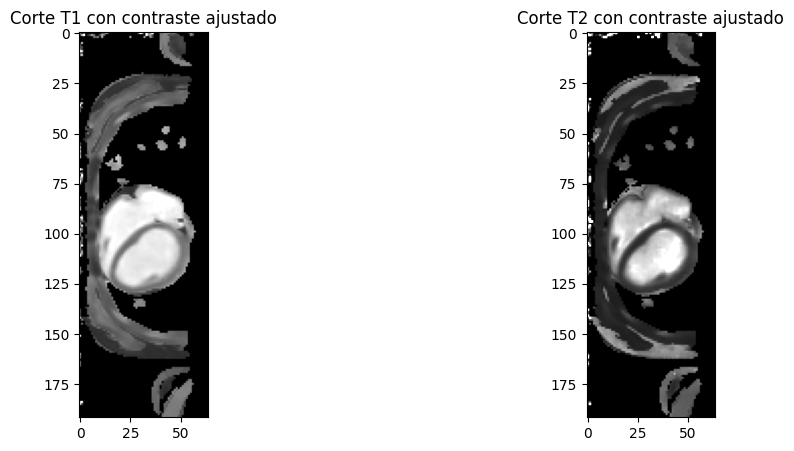

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar forzando el orden de los ejes (Fortran order True)
# Esto es vital porque el encabezado del .npy lo requiere
t1_map = np.load("mapa_T1.npy", allow_pickle=True)
t2_map = np.load("mapa_T2.npy", allow_pickle=True)

# 2. Limpieza de datos: convertir NaN a 0 (o al valor mínimo presente)
# Los mapas de MRI suelen tener ruido en los bordes, pero no deberían ser todo NaN
t1_map = np.nan_to_num(t1_map, nan=0.0)
t2_map = np.nan_to_num(t2_map, nan=0.0)

print("Shape T1:", t1_map.shape) 
print("T1 min/max:", t1_map.min(), t1_map.max())

# 3. Visualización con ajustes de contraste
# A veces la imagen es negra porque el rango de valores es muy alto (ej. 0 a 3000ms)
# y estás usando un colormap que no se ajusta.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
mid_z = t1_map.shape[0] // 2

# Usamos vmin y vmax para mejorar el contraste visual
axes[0].imshow(t1_map[mid_z, :, :], cmap="gray", vmin=0, vmax=np.percentile(t1_map, 99))
axes[0].set_title("Corte T1 con contraste ajustado")

axes[1].imshow(t2_map[mid_z, :, :], cmap="gray", vmin=0, vmax=np.percentile(t2_map, 99))
axes[1].set_title("Corte T2 con contraste ajustado")
plt.show()

INTENTO A 

- Umbralizacion + centroide

Centroide (voxeles): (np.float64(82.21902435679883), np.float64(89.43802985893282), np.float64(32.46645412317238))


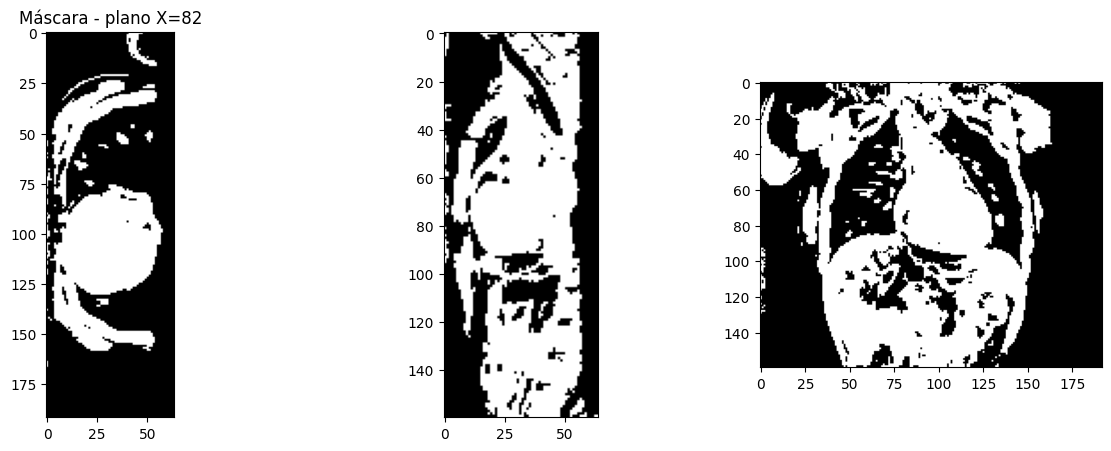

In [ ]:
#paso 2: donde esta el corazon ??? 
from scipy import ndimage


#AJUSTAR VALORES 
umbral_bajo = 500   
umbral_alto = 1800  

mascara_t1 = (t1_map > umbral_bajo) & (t1_map < umbral_alto)

#LIMPIEZA DE RUIDOS 
mascara_etiquetada, num_labels = ndimage.label(mascara_t1)
tamaños = ndimage.sum(mascara_t1, mascara_etiquetada, range(num_labels+1))
label_mas_grande = np.argmax(tamaños[1:]) + 1
mascara_limpia = (mascara_etiquetada == label_mas_grande)

#CENTROIDE CORAZON
centroide = ndimage.center_of_mass(mascara_limpia)
print("Centroide (voxeles):", centroide)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
mid = [int(centroide[i]) for i in range(3)]
ax[0].imshow(mascara_limpia[mid[0],:,:], cmap="gray")
ax[0].set_title(f"Máscara - plano X={mid[0]}")
ax[1].imshow(mascara_limpia[:,mid[1],:], cmap="gray")
ax[2].imshow(mascara_limpia[:,:,mid[2]], cmap="gray")
plt.savefig("mascara_corazon.png", dpi=150)

El miocardio tiene valores T1 y T2 distintos del fondo (aire, pulmón).Se crea una mascara binaria.

- Umbral elegido y justificación.
- ¿La máscara capturó bien el corazón? ¿Incluyó estructuras ajenas (hígado, aorta)?
- Centroide calculado.
- Problemas encontrados (ej: "la cavidad ventricular quedó excluida").


INTENTO B 
- Seleccion manual de puntos

In [ ]:
#PASO 3 - SACAR EL EJE LARGO VI 
#con apex y base, su eje largo sera el vector entre ambos puntos

In [ ]:
#PASO 4  sistema de coordenadas de eje corto. 
#perpendicular al eje largo, y con centro en el centroide. Tenemos que sacar un sistema ortonormal 

DATOS CARGADOS
Shape T1: (160, 192, 64)
Shape T2: (160, 192, 64)
Suavizado gaussiano aplicado.


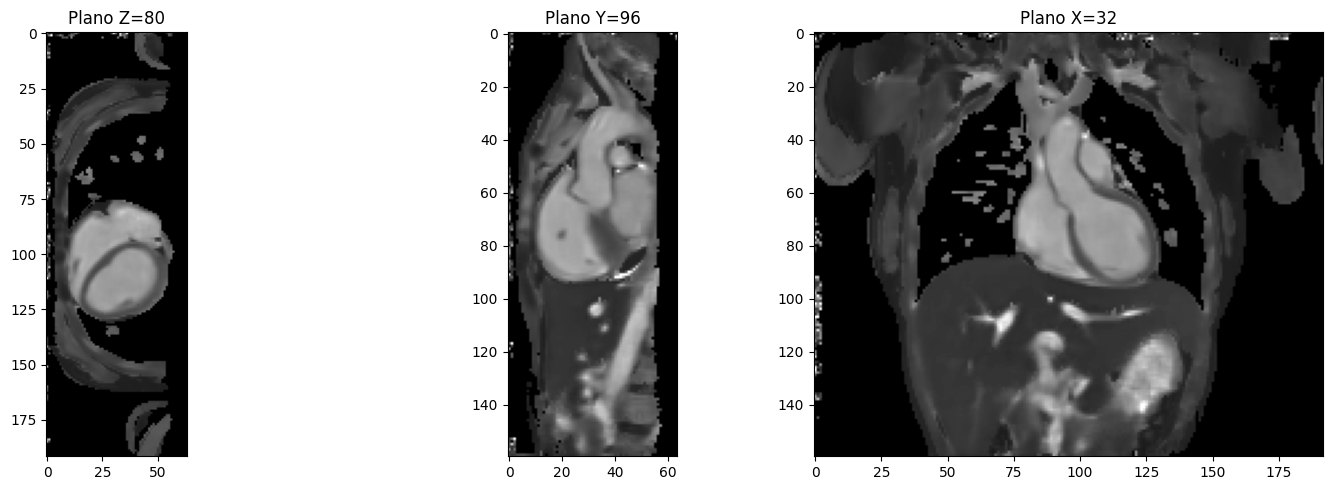

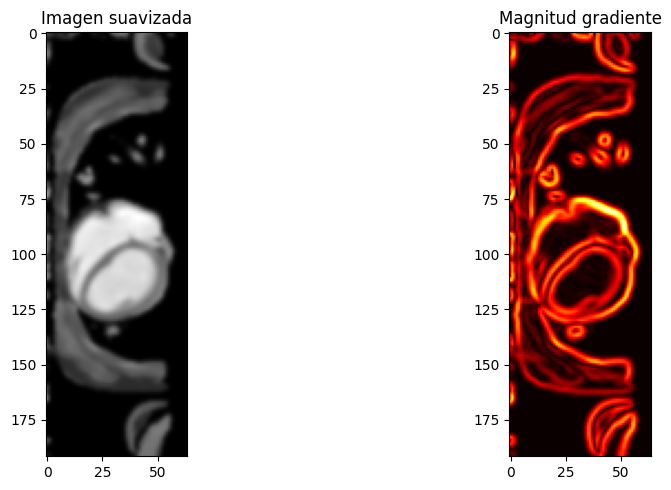

LANDMARKS
Apex: [10. 96. 32.]
Base: [55. 96. 32.]
Lateral: [ 30. 120.  32.]


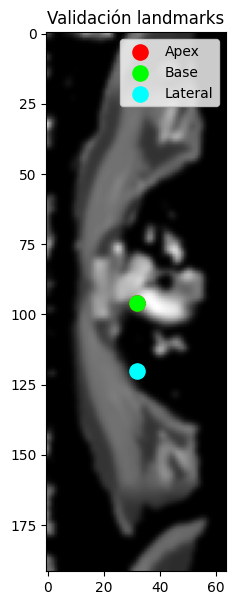

EJE LARGO
[1. 0. 0.]
ORTOGONALIDAD
dot(eje,u): 0.0
dot(eje,v): 0.0
dot(u,v): 0.0
GENERANDO SAX
VALIDACIÓN
T1 min/max: 0.0 1832.7857052679353
T2 min/max: 0.0 422.8232981827268


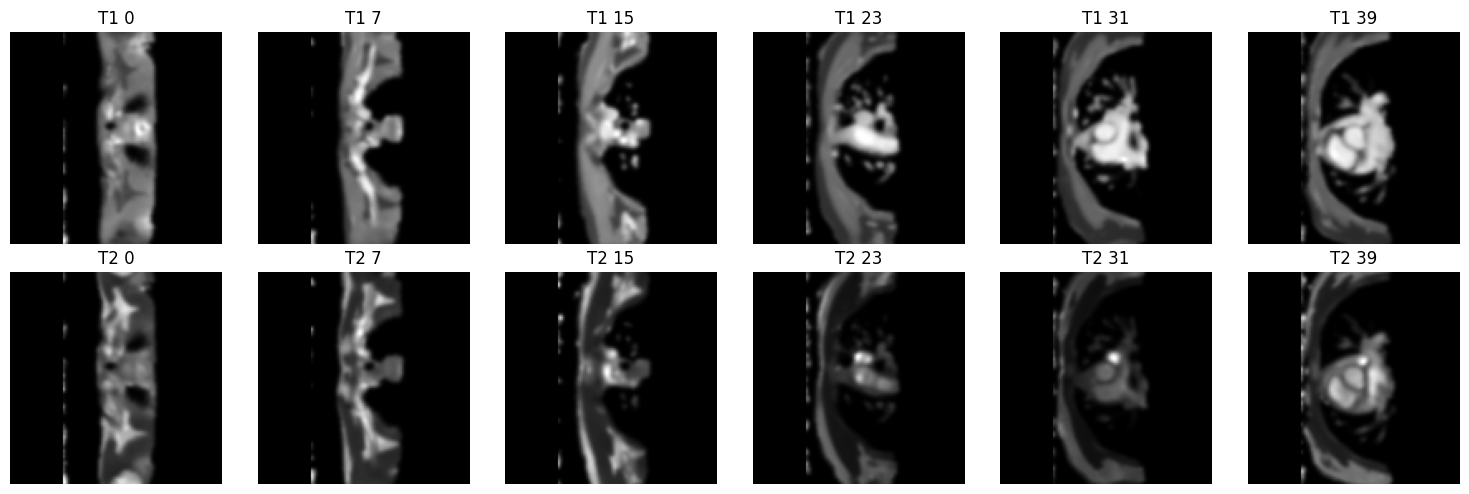

PIPELINE FINALIZADO
Archivos exportados:
- mapa_T1_SAX.npy
- mapa_T2_SAX.npy
- preview_SAX.png
- metadata.json
- README.txt


In [14]:

import numpy as np
import matplotlib.pyplot as plt
import json

from scipy.ndimage import (
    gaussian_filter,
    sobel,
    map_coordinates
)

# =========================================================
# 1. CARGA DE DATOS
# =========================================================

t1 = np.load("mapa_T1.npy")
t2 = np.load("mapa_T2.npy")

# Limpieza básica
t1 = np.nan_to_num(t1, nan=0.0)
t2 = np.nan_to_num(t2, nan=0.0)

print("===================================")
print("DATOS CARGADOS")
print("===================================")

print("Shape T1:", t1.shape)
print("Shape T2:", t2.shape)

# =========================================================
# 2. SUAVIZADO GAUSSIANO
# Reduce ruido
# =========================================================

sigma = 1.0

t1_smooth = gaussian_filter(
    t1,
    sigma=sigma
)

t2_smooth = gaussian_filter(
    t2,
    sigma=sigma
)

print("Suavizado gaussiano aplicado.")

# =========================================================
# 3. VISUALIZACIÓN INICIAL
# Revisar orientación anatómica
# =========================================================

mid_z = t1.shape[0] // 2
mid_y = t1.shape[1] // 2
mid_x = t1.shape[2] // 2

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

axes[0].imshow(
    t1[mid_z,:,:],
    cmap='gray'
)
axes[0].set_title(f'Plano Z={mid_z}')

axes[1].imshow(
    t1[:,mid_y,:],
    cmap='gray'
)
axes[1].set_title(f'Plano Y={mid_y}')

axes[2].imshow(
    t1[:,:,mid_x],
    cmap='gray'
)
axes[2].set_title(f'Plano X={mid_x}')

plt.tight_layout()
plt.show()

# =========================================================
# 4. VISUALIZACIÓN DE BORDES
# Ayuda visual para landmarks
# =========================================================

gx = sobel(
    t1_smooth[mid_z],
    axis=0
)

gy = sobel(
    t1_smooth[mid_z],
    axis=1
)

gradiente = np.sqrt(
    gx**2 + gy**2
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

axes[0].imshow(
    t1_smooth[mid_z],
    cmap='gray'
)

axes[0].set_title(
    "Imagen suavizada"
)

axes[1].imshow(
    gradiente,
    cmap='hot'
)

axes[1].set_title(
    "Magnitud gradiente"
)

plt.tight_layout()
plt.show()

# =========================================================
# 5. LANDMARKS
# SEMI-MANUALES
#
# Coordenadas [Z,Y,X]
#
# Debes ajustar visualmente
# =========================================================

p_apex = np.array([
    10,
    96,
    32
], dtype=float)

p_base = np.array([
    55,
    96,
    32
], dtype=float)

p_lateral = np.array([
    30,
    120,
    32
], dtype=float)

print("===================================")
print("LANDMARKS")
print("===================================")

print("Apex:", p_apex)
print("Base:", p_base)
print("Lateral:", p_lateral)

# =========================================================
# 6. VISUALIZACIÓN LANDMARKS
# =========================================================

plt.figure(figsize=(7,7))

plt.imshow(
    t1_smooth[int(p_lateral[0])],
    cmap='gray'
)

plt.scatter(
    p_apex[2],
    p_apex[1],
    c='red',
    s=120,
    label='Apex'
)

plt.scatter(
    p_base[2],
    p_base[1],
    c='lime',
    s=120,
    label='Base'
)

plt.scatter(
    p_lateral[2],
    p_lateral[1],
    c='cyan',
    s=120,
    label='Lateral'
)

plt.legend()

plt.title(
    "Validación landmarks"
)

plt.show()

# =========================================================
# 7. EJE LARGO
# =========================================================

eje = p_base - p_apex

eje = eje / np.linalg.norm(eje)

print("===================================")
print("EJE LARGO")
print("===================================")

print(eje)

# =========================================================
# 8. BASE ORTONORMAL
# SIN GRAM-SCHMIDT
# =========================================================

aux = p_lateral - p_apex

aux = aux / np.linalg.norm(aux)

u = np.cross(
    eje,
    aux
)

u = u / np.linalg.norm(u)

v = np.cross(
    eje,
    u
)

v = v / np.linalg.norm(v)

print("===================================")
print("ORTOGONALIDAD")
print("===================================")

print("dot(eje,u):", np.dot(eje,u))
print("dot(eje,v):", np.dot(eje,v))
print("dot(u,v):", np.dot(u,v))

# =========================================================
# 9. REFORMATEO SAX
# =========================================================

def reformatear_sax(
    volumen,
    apex,
    base,
    eje,
    u,
    v,
    tamaño=128,
    nslices=40
):

    sax = np.zeros(
        (nslices, tamaño, tamaño)
    )

    half = tamaño // 2

    rango = np.linspace(
        -half,
        half,
        tamaño
    )

    UU, VV = np.meshgrid(
        rango,
        rango
    )

    longitud = np.linalg.norm(
        base - apex
    )

    offsets = np.linspace(
        0,
        longitud,
        nslices
    )

    for i, d in enumerate(offsets):

        centro = apex + d * eje

        puntos = (
            centro[None,None,:]
            + UU[:,:,None] * u[None,None,:]
            + VV[:,:,None] * v[None,None,:]
        )

        coords = [
            puntos[:,:,0].ravel(),
            puntos[:,:,1].ravel(),
            puntos[:,:,2].ravel()
        ]

        valores = map_coordinates(
            volumen,
            coords,
            order=1,
            mode='constant',
            cval=0
        )

        sax[i] = valores.reshape(
            tamaño,
            tamaño
        )

    return sax

# =========================================================
# 10. GENERAR SAX
# =========================================================

print("===================================")
print("GENERANDO SAX")
print("===================================")

t1_sax = reformatear_sax(
    t1_smooth,
    p_apex,
    p_base,
    eje,
    u,
    v
)

t2_sax = reformatear_sax(
    t2_smooth,
    p_apex,
    p_base,
    eje,
    u,
    v
)

# =========================================================
# 11. VALIDACIÓN NUMÉRICA
# =========================================================

print("===================================")
print("VALIDACIÓN")
print("===================================")

print(
    "T1 min/max:",
    np.min(t1_sax),
    np.max(t1_sax)
)

print(
    "T2 min/max:",
    np.min(t2_sax),
    np.max(t2_sax)
)

# =========================================================
# 12. VISUALIZACIÓN SAX
# =========================================================

nslices = t1_sax.shape[0]

indices = np.linspace(
    0,
    nslices - 1,
    6,
    dtype=int
)

fig, axes = plt.subplots(
    2,
    6,
    figsize=(15,5)
)

for j, idx in enumerate(indices):

    axes[0,j].imshow(
        t1_sax[idx],
        cmap='gray',
        origin='lower'
    )

    axes[0,j].axis('off')

    axes[0,j].set_title(
        f"T1 {idx}"
    )

    axes[1,j].imshow(
        t2_sax[idx],
        cmap='gray',
        origin='lower'
    )

    axes[1,j].axis('off')

    axes[1,j].set_title(
        f"T2 {idx}"
    )

plt.tight_layout()

plt.savefig(
    "preview_SAX.png",
    dpi=300
)

plt.show()

# =========================================================
# 13. EXPORTACIÓN
# =========================================================

np.save(
    "mapa_T1_SAX.npy",
    t1_sax
)

np.save(
    "mapa_T2_SAX.npy",
    t2_sax
)

# =========================================================
# 14. METADATA
# =========================================================

metadata = {

    "metodologia":
    "Pipeline semi-manual de reformateo SAX",

    "apex":
    p_apex.tolist(),

    "base":
    p_base.tolist(),

    "lateral":
    p_lateral.tolist(),

    "eje_largo":
    eje.tolist(),

    "vector_u":
    u.tolist(),

    "vector_v":
    v.tolist(),

    "sigma_gaussiano":
    sigma,

    "nslices":
    int(nslices),

    "slice_size":
    int(t1_sax.shape[1])
}

with open(
    "metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

# =========================================================
# 15. README
# =========================================================

readme = """

PIPELINE SAX - GEOMETRÍA

Archivos entregados:
- mapa_T1_SAX.npy
- mapa_T2_SAX.npy
- preview_SAX.png
- metadata.json

Descripción:
Se aplicó un pipeline semi-manual para reformateo
cardíaco en eje corto (SAX).

Etapas:
1. Suavizado gaussiano
2. Visualización de gradientes
3. Selección semi-manual de landmarks
4. Construcción de eje largo
5. Reformateo SAX mediante interpolación lineal

Importante:
Los volúmenes T1 y T2 comparten exactamente
la misma geometría espacial y orientación.

Los archivos SAX están listos para:
- segmentación
- análisis morfológico
- generación de mapas regionales
"""

with open(
    "README.txt",
    "w"
) as f:

    f.write(readme)

print("===================================")
print("PIPELINE FINALIZADO")
print("===================================")

print("Archivos exportados:")
print("- mapa_T1_SAX.npy")
print("- mapa_T2_SAX.npy")
print("- preview_SAX.png")
print("- metadata.json")
print("- README.txt")
